In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("2feature_cleaned_data.csv")

In [4]:
print("\n🔹 SELECTING FEATURES")

features = ['OPEN','HIGH','LOW','VOLUME','MA_20','MA_50']

X = data[features]
y = data['Target']

print("Features selected:", features)
print("X shape:", X.shape)


🔹 SELECTING FEATURES
Features selected: ['OPEN', 'HIGH', 'LOW', 'VOLUME', 'MA_20', 'MA_50']
X shape: (1444, 6)


In [5]:
from sklearn.model_selection import train_test_split

print("\n🔹 SPLITTING DATA")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


🔹 SPLITTING DATA
Train size: (1155, 6)
Test size: (289, 6)


In [6]:
from sklearn.linear_model import LogisticRegression

print("\n🔹 TRAINING MODEL")

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


🔹 TRAINING MODEL
Model trained successfully!


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
print("\n🔹 MAKING PREDICTIONS")

y_pred = model.predict(X_test)

print("Predictions done!")


🔹 MAKING PREDICTIONS
Predictions done!


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n🔹 MODEL EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


🔹 MODEL EVALUATION
Accuracy: 0.45674740484429066

Confusion Matrix:
 [[ 21 141]
 [ 16 111]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.13      0.21       162
           1       0.44      0.87      0.59       127

    accuracy                           0.46       289
   macro avg       0.50      0.50      0.40       289
weighted avg       0.51      0.46      0.38       289



In [9]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=features)

print("\n🔹 FEATURE IMPORTANCE")
print(importance.sort_values(ascending=False))


🔹 FEATURE IMPORTANCE
MA_50     1.040227e-03
OPEN      8.643117e-04
HIGH      4.131564e-04
VOLUME    1.964383e-08
MA_20    -1.096621e-03
LOW      -1.228348e-03
dtype: float64


In [11]:
y_pred_log= model.predict(X_test)

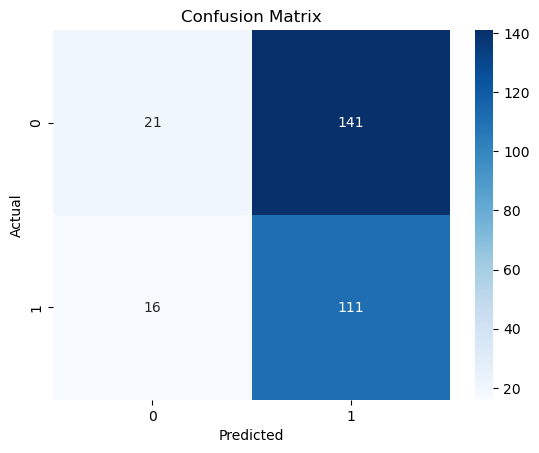

In [12]:
sns.heatmap(confusion_matrix(y_test, y_pred_log),
            annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


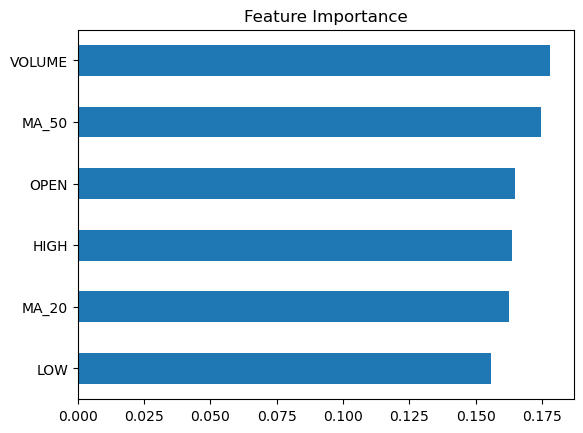

In [15]:
importance = pd.Series(rf_model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()